In [1]:
using LinearAlgebra
using LinearOperators
using SparseArrays

From the discretization of the poisson equation in d dimensions, we get the system:

L U = F

where
- L is the matrix for discretized laplace operator
- U is the numerical solution on the grid we want
- F is the rhs of the equation evaluated on the grid

Here, we try 3 different approaches to solving the system in julia.
- L \ F
- conjugate grads with matrix L and vector F
- conjugate grads with linear operator L and vector F

In [2]:
function get_1d_laplace_op_matrix(n)
	off = ones(n-1)
	diag = ones(n)
	spdiagm(-1 => off, 0 => -2diag, 1 => off)
end

get_1d_laplace_op_matrix (generic function with 1 method)

In [3]:
# L
# E L, L E
# E E L, E L E, L E E
# E E E L, E E L E, E L E E, L E E E
# (E E E L), (E E L) (E), (E L) (E E), (L) (E E E)
# E ... E L = L of size n^(k+1) if E is there k times

# (E E E L), (E E L) (E), (E L) (E E), (L) (E E E)

# E E E x L
# (E E x L) x (E)
# (E x L) x (E E)
# L x E E E

function get_laplace_op_matrix(n, d)
	L = get_1d_laplace_op_matrix(n)
	if d == 1
		L_full = L
	elseif d == 2
		E = sparse(I, n, n)
		L_full = kron(E, L) + kron(L, E)
	elseif d >= 3
		# step 1
		size = n^(d-1)
		E = sparse(I, size, size)
		L_full = kron(E, L)
		# step 2:d-1
		for k in 2:(d-1)
			n_Es_lhs = d-k
			n_Es_rhs = k-1
			# lhs
			size = n^(n_Es_lhs)
			E = sparse(I, size, size)
			kron_lhs = kron(E, L)
			# rhs
			size = n^(n_Es_rhs)
			E = sparse(I, size, size)
			L_full += kron(kron_lhs, E)
		end
		# step d
		size = n^(d-1)
		E = sparse(I, size, size)
		L_full += kron(L, E)
	end
end

# 4 points, 3 dims
#get_laplace_op_matrix(4, 3)

get_laplace_op_matrix (generic function with 1 method)

In [4]:
#get_laplace_op_matrix(3, 2)

In [5]:
#Matrix(L_full)

## define RHS and solve using different methods

$\Delta u = f \:\:\text{on}\:\:\Omega$

$u = g \:\:\text{on}\:\:\partial\Omega$

supp 1D:

$ \partial u / \partial x \approx \frac{u(x+h/2) - u(x-h/2)}{h}$

$\Delta u(x) \approx \frac{u(x+h) - 2u(x) + u(x-h)}{h^2}$

$ u_{i-1} - 2u_i + u_{i+1} = h^2 f_i$

$ i = 0,1,...,n,n+1 $

boundary: $\:i=0, \:i=n+1 $

we know $\:u_0, \:u_{n+1}\:$ from BC

we need $n$ equation for $n$ unknowns ($u_1,...,u_n$)

$ u_0 - 2u_1 + u_2 = h^2 f_1 $

$ u_1 - 2u_2 + u_3 = h^2 f_2 $

...

$ u_{n-2} - 2u_{n-1} + u_{n} = h^2 f_{n-1} $

$ u_{n-1} - 2u_n + u_{n+1} = h^2 f_n $

we get

$ L U = F $

where
- $L$ matrix of size $n \times n$
- $U = (u_1, u_2, ..., u_{n-1}, u_n)$
- $F = h^2(f_1, f_2, ..., f_{n-1}, f_n) - (u_0, 0, ..., 0, u_{n+1})$

In [6]:
n = 50
d = 2
N = n^d

2500

In [7]:
h = 1 / (n+1)

0.0196078431372549

In [8]:
function u_analytic_fun(x)
    prod(sin.(pi*x))

    #prod(x)*prod(1 .- x)
end

function f_fun(x)
    d = length(x)
    -d*pi^2 * prod(sin.(pi*x))

    #d = length(x)
    #res = 0.0
    #p = 1.0
    #y = zeros(d)
    #for dim in 1:d
    #    # 1
    #    p = 1.0
    #    y .= x
    #    y[dim] = 1.0
    #    p *= prod(y)
    #    # 2
    #    y .= x
    #    y = 1 .- x
    #    y[dim] = 1.0
    #    p *= prod(y)
    #    res += p
    #end
    #res *= -2
    #res
end

f_fun (generic function with 1 method)

### here we go

In [9]:
function get_grid_points_as_1d_vect(n, d)
    a = 0
    b = 1
    h = 1/(n+1)
    xs = [range(h, 1-h; length=n) for _ in 1:d]
    coords = collect(Iterators.product(xs...))
    [collect(x) for x in coords[1:end]]
end
#f.(grid_points_as_1d_vect)

get_grid_points_as_1d_vect (generic function with 1 method)

In [10]:
n^d

2500

In [11]:
grid_points_as_1d_vect = get_grid_points_as_1d_vect(n,d);

In [12]:
U_analytic = u_analytic_fun.(grid_points_as_1d_vect);

In [13]:
F = h^2 * f_fun.(grid_points_as_1d_vect);

In [14]:
L = get_laplace_op_matrix(n,d);

In [15]:
using IterativeSolvers
U_cg = cg(L, F; verbose=true);

  1	1.56e-14



In [16]:
U_direct = L \ F;

### operator approach

In [17]:
function laplace_operator!(v_new, v)

    # from vector of value to values on a grid
    U = reshape(v, ntuple(i -> n, d)) 

    # apply the laplace stencil on every value on the grid
    LU = zeros(size(U));
    for dim in 1:d
        index_rs = ntuple(i -> i == dim ? (2:n) : Colon(), d)
        index_ls = ntuple(i -> i == dim ? (1:(n-1)) : Colon(), d)
        LU[index_rs...] .+= U[index_ls...]
        LU[index_ls...] .+= U[index_rs...]
    end
    LU .-= 2*d*U

    v_new .= vec(LU)
end


laplace_operator! (generic function with 1 method)

In [18]:
L_op = LinearOperator(Float64, N, N, true, true, laplace_operator!)

Linear operator
  nrow: 2500
  ncol: 2500
  eltype: Float64
  symmetric: true
  hermitian: true
  nprod:   0
  ntprod:  0
  nctprod: 0



In [19]:
U_cg_op = cg(L_op, F; maxiter=100, verbose=true)

  1	1.66e-14



2500-element Vector{Float64}:
 0.0037909437537744046
 0.007567507159394277
 0.011315364418291278
 0.015020298624144182
 0.01866825569247423
 0.022245397672601412
 0.025738155239731303
 0.029133279168051793
 0.03241789058958485
 0.035579529848144095
 0.0386062037630784
 0.04148643112351421
 0.04420928624052088
 ⋮
 0.041486431123514494
 0.03860620376307865
 0.03557952984814433
 0.03241789058958508
 0.029133279168051984
 0.025738155239731456
 0.02224539767260158
 0.018668255692474357
 0.015020298624144297
 0.011315364418291353
 0.007567507159394338
 0.003790943753774453

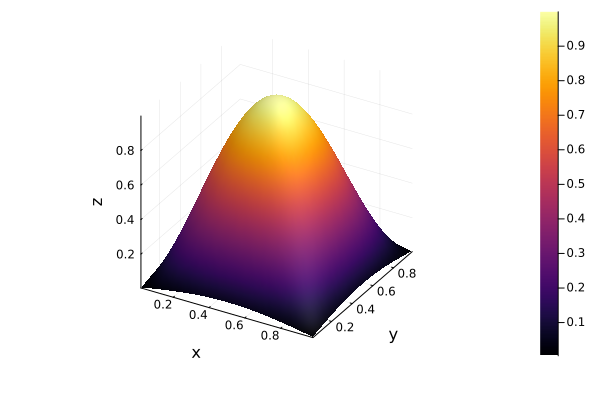

In [20]:
if d == 2
    using Plots

    # Create a grid
    x = y = h:h:(1-h)
    z = [F[i*n+j] for i in 0:(n-1), j in 1:n]
    z = [U_cg[i*n+j] for i in 0:(n-1), j in 1:n]
    z = [U_cg_op[i*n+j] for i in 0:(n-1), j in 1:n]
    z = [U_analytic[i*n+j] for i in 0:(n-1), j in 1:n]
    z = [U_direct[i*n+j] for i in 0:(n-1), j in 1:n]

    # Make the surface plot
    surface(x, y, z, xlabel="x", ylabel="y", zlabel="z")
end

In [21]:
if d == 1
    using CairoMakie
    CairoMakie.activate!()
    grid_points = collect(range(h,1-h, length=n));
    scatter(grid_points, U_analytic, color=:gray0)
    lines!(grid_points, U_direct, color=:tomato)
    lines!(grid_points, U_cg, color=:mediumblue)
    lines!(grid_points, U_cg_op, color=:limegreen)
    current_figure()
end

In [22]:
#n_trials = 8
#n_mult = 8
#max_jacobi = zeros(n_trials)
#max_gs = zeros(n_trials)
#max_direct = zeros(n_trials)
#
#for i in 1:n_trials
#    n = n_mult*i
#    h = 1/(n+1)
#    grid_points = collect(range(h,1-h, length=n))
#    L = get_laplace_op_matrix(n)
#    F = h^2 * f_fun(grid_points)
#    U_jacobi = jacobi(L, F)
#    U_gs = gauss_seidel(L, F; maxiter=100)
#    U_direct = L \ F
#
#    max_jacobi[i] = maximum(U_jacobi)
#    max_gs[i] = maximum(U_gs)
#    max_direct[i] = maximum(U_direct)
#end